# Analytical differentiation with SymPy: fitting a logistic model

In this notebook we fit a **logistic curve** to experimental data that relate **illumination** and **perceived clarity**.

We will use:
- **SymPy** to compute the derivatives analytically,
- **NumPy** to evaluate those derivatives numerically,
- **gradient descent** to optimize the model parameters.


## Learning goals

By the end of the exercise you should be able to:
1. define a symbolic model and a symbolic loss with **SymPy**,
2. compute the gradients with respect to the model parameters,
3. convert symbolic expressions into numerical functions with `lambdify`,
4. implement gradient descent using those analytical derivatives,
5. interpret the fitted logistic curve.


## 1. Load and visualize the data

The file `clarity_noisy_data.csv` contains two columns:
- `Illumination`
- `Clarity`

The goal is to model the clarity score as a function of illumination.


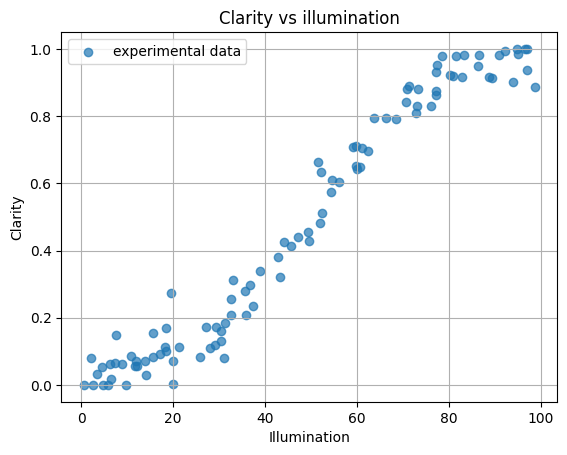

In [37]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp

# Read the data from CSV file
data = pd.read_csv('data/clarity_noisy_data.csv')

# Extract columns of the data file
x_data = data["Illumination"].values # Features
y_data = data["Clarity"].values # Targets

# Plot the experimental data
def plot_data(x, y):
    plt.scatter(x, y, alpha=0.7, label="experimental data")
    plt.xlabel("Illumination")
    plt.ylabel("Clarity")
    plt.title("Clarity vs illumination")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_data(x_data, y_data)


## 2. Logistic model

We model the predicted clarity as

$$
\hat y = \sigma(wx+b), 
\qquad
\sigma(z)=\frac{1}{1+e^{-z}}.
$$

For one data point $(x, y_t)$, define the single-sample loss

$$
\mathcal{L}_j = (\hat y - y_t)^2.
$$

### Exercise 1
Create the symbolic objects:
- `x`, `w`, `b`, `y_t`
- `z = w*x + b`
- `y_pred = sigma(z)`
- `loss_j = (y_pred - y_t)**2`


In [38]:

x, w, b, y_t = sp.symbols("x w b y_t", real=True)

z = w * x + b
y_pred = 1 / (1 + sp.exp(-z))
loss_j = (y_pred - y_t) ** 2

display(y_pred)
display(loss_j)


1/(exp(-b - w*x) + 1)

(-y_t + 1/(exp(-b - w*x) + 1))**2

## 3. Analytical derivatives

We now compute the derivatives of the **single-sample** loss with respect to the trainable parameters:

$$
\frac{\partial \mathcal{L}_j}{\partial w},
\qquad
\frac{\partial \mathcal{L}_j}{\partial b}.
$$

### Exercise 2
Use `sp.diff` and simplify the result.


In [39]:

dL_dw = sp.simplify(sp.diff(loss_j, w))
dL_db = sp.simplify(sp.diff(loss_j, b))

display(dL_dw)
display(dL_db)


-2*x*(y_t*(exp(b + w*x) + 1) - exp(b + w*x))*exp(b + w*x)/(exp(b + w*x) + 1)**3

2*(-y_t*(exp(b + w*x) + 1) + exp(b + w*x))*exp(b + w*x)/(exp(b + w*x) + 1)**3

## 4. Convert symbolic expressions to numerical functions

To train the model, we need numerical versions of:
- the prediction,
- the single-sample loss,
- the two partial derivatives.


In [40]:

y_pred_numeric = sp.lambdify((x, w, b), y_pred, "numpy")
loss_numeric = sp.lambdify((x, y_t, w, b), loss_j, "numpy")
dL_dw_numeric = sp.lambdify((x, y_t, w, b), dL_dw, "numpy")
dL_db_numeric = sp.lambdify((x, y_t, w, b), dL_db, "numpy")


## 5. Gradient descent

For the full dataset, the MSE is

$$
\mathcal{L}(w,b)=\frac{1}{N}\sum_{j=1}^N \mathcal{L}_j.
$$

Therefore, the gradients used in training are the averages over all samples:

$$
\frac{\partial \mathcal{L}}{\partial w}= \frac{1}{N}\sum_{j=1}^N \frac{\partial \mathcal{L}_j}{\partial w},\qquad\frac{\partial \mathcal{L}}{\partial b}=
\frac{1}{N}\sum_{j=1}^N \frac{\partial \mathcal{L}_j}{\partial b}.
$$

### Exercise 3
Implement:
1. one gradient-descent update step,
2. a training loop that stores the loss history.


In [41]:

def gradient_descent_step(theta, grad, lr):
    return theta - lr * grad


def train_model(x_data, y_data, n_epochs, lr, w0, b0, tol=1e-6, verbose_every=5000):
    w_val = float(w0)
    b_val = float(b0)

    history = {"loss": [], "w": [], "b": []}

    for epoch in range(n_epochs + 1):
        current_loss = np.mean(loss_numeric(x_data, y_data, w_val, b_val))

        history["loss"].append(current_loss)
        history["w"].append(w_val)
        history["b"].append(b_val)

        if epoch % verbose_every == 0:
            print(f"Epoch {epoch:5d} | loss = {current_loss:.6f} | w = {w_val:.6f} | b = {b_val:.6f}")

        if current_loss < tol:
            print(f"Stopping early because loss < {tol}.")
            break

        grad_w = np.mean(dL_dw_numeric(x_data, y_data, w_val, b_val))
        grad_b = np.mean(dL_db_numeric(x_data, y_data, w_val, b_val))

        new_theta = gradient_descent_step(
            np.array([w_val, b_val]),
            np.array([grad_w, grad_b]),
            lr,
        )
        w_val, b_val = new_theta

    return w_val, b_val, history


## 6. Run the optimization

Use the following initialization and hyperparameters:
- `w0 = 0.5`
- `b0 = 0.5`
- `lr = 0.01`
- `n_epochs = 50000`

### Exercise 4
Train the model and inspect the final parameters.


In [42]:

w0 = 0.5
b0 = 0.5
lr = 0.01
n_epochs = 50000

w_fit, b_fit, history = train_model(x_data, y_data, n_epochs=n_epochs, lr=lr, w0=w0, b0=b0)

print(f"\nFinal parameters: w = {w_fit:.6f}, b = {b_fit:.6f}")
print(f"Final MSE: {history['loss'][-1]:.6f}")


Epoch     0 | loss = 0.392883 | w = 0.500000 | b = 0.500000
Epoch  5000 | loss = 0.019818 | w = 0.036278 | b = -1.854912
Epoch 10000 | loss = 0.006908 | w = 0.053411 | b = -2.528128
Epoch 15000 | loss = 0.004481 | w = 0.059591 | b = -2.872687
Epoch 20000 | loss = 0.003501 | w = 0.063568 | b = -3.092679
Epoch 25000 | loss = 0.003022 | w = 0.066367 | b = -3.246767
Epoch 30000 | loss = 0.002761 | w = 0.068441 | b = -3.360591
Epoch 35000 | loss = 0.002608 | w = 0.070030 | b = -3.447595
Epoch 40000 | loss = 0.002515 | w = 0.071276 | b = -3.515684
Epoch 45000 | loss = 0.002456 | w = 0.072269 | b = -3.569887
Epoch 50000 | loss = 0.002418 | w = 0.073070 | b = -3.613588

Final parameters: w = 0.073070, b = -3.613596
Final MSE: 0.002418


## 7. Visualize the result

### Exercise 5
Plot:
1. the data points,
2. the initial logistic model,
3. the fitted logistic model,
4. the loss as a function of the epoch.


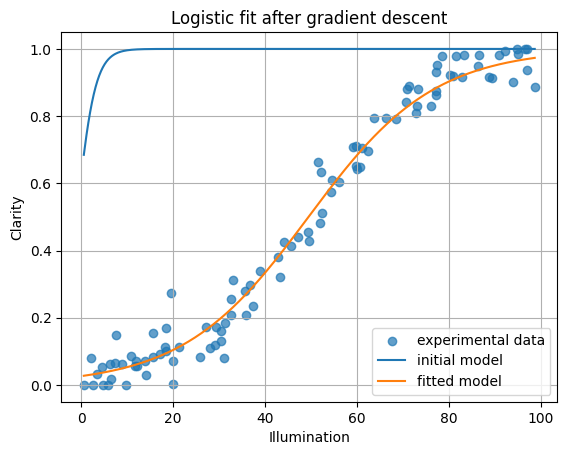

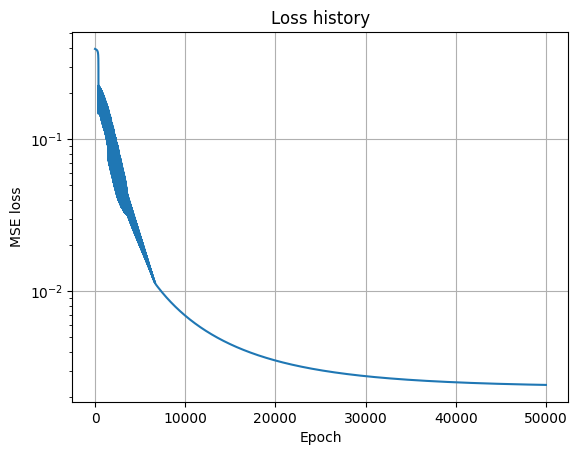

In [43]:

x_plot = np.linspace(x_data.min(), x_data.max(), 500)

y_init = y_pred_numeric(x_plot, w0, b0)
y_fit = y_pred_numeric(x_plot, w_fit, b_fit)

plt.scatter(x_data, y_data, alpha=0.7, label="experimental data")
plt.plot(x_plot, y_init, label="initial model")
plt.plot(x_plot, y_fit, label="fitted model")
plt.xlabel("Illumination")
plt.ylabel("Clarity")
plt.title("Logistic fit after gradient descent")
plt.grid(True)
plt.legend()
plt.show()

plt.plot(history["loss"])
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Loss history")
plt.grid(True)
plt.show()


## 8. Discussion

Answer these questions:
1. What is the role of `w` in the logistic curve?
2. What is the role of `b`?
3. Why does the loss decrease more slowly near the end of training?
4. Describe the sequence of intermediate steps involved when differentiating the loss with respect to a parameter in this model.


### Possible discussion points

- **`w` controls the steepness** of the transition from low clarity to high clarity.
- **`b` shifts the curve horizontally** because the midpoint occurs when `wx + b = 0`.
- Near the optimum, the gradients are smaller, so gradient descent takes shorter steps.
- The derivative with respect to each parameter is built by repeatedly applying the **chain rule**:
  loss → sigmoid output → affine map → parameter.

In other words, this small exercise mirrors the same logic used when differentiating neural networks layer by layer.
